In [1]:
!nvidia-smi

Mon Dec  8 12:36:06 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100-SXM2-32GB           On  |   00000000:3B:00.0 Off |                    0 |
| N/A   38C    P0             40W /  300W |       0MiB /  32768MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Credit Card Fraud Detection

Link: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

Time taken: 90 minutes (deep work)
Version control: https://github.com/abaj8494/10khrs-ai-ml-dl/blob/main/projects/interview/credit-card-fraud.ipynb

## Problem Statement

It is important that credit card companies are able to recognise fraudulent credit card transactions so that customers are not charged for items that they did not purchase.

This dataset contains transactions made by credit cards in September 2013 by European cardholders.

This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is **highly unbalanced**, the positive class (frauds) account for 0.172% of all transactions. (considering mixture loss, focal perhaps).

It contains only numerical input variables which are the result of a PCA transformation (naturally all the feature would be too large of a dataset to share; also confidentiality!). 28 features with only 'Time' and 'Amount' not being transformed.

'Time' contains *seconds elapsed* between each transaction and the **first** transaction in the dataset. 'Amount' is the transaction amount (naturally) -- this feature can be used for example-dependant cost-sensitive learning. Feature 'Class' is the response variable and takes value `1` in case of fraud, else `0`.

Importantly, given the class imbalance ratio, we should measure accuracy using the **Area Under the Precision-Recall Curve** (AUPRC). Realise that **confusion matrix accuracy** is not meaningful for unbalanced classification.

In [11]:
import kagglehub

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

/srv/scratch/z5362216/.venvs/kits/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 66.0M/66.0M [00:17<00:00, 3.89MB/s]

Extracting files...


Path to dataset files: /home/z5362216/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3


## Exploratory Data Analysis

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [18]:
import os

csv_path = Path(path + '/' + 'creditcard.csv')
df = pd.read_csv(csv_path)

In [19]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [21]:
df.shape

(284807, 31)

In [22]:
# ^as expected from the kaggle description brief.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [23]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### Class Imbalances

In [26]:
# class imbalance details
df["Class"].value_counts() # how many of each (raw)

Class
0    284315
1       492
Name: count, dtype: int64

In [27]:
df["Class"].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

In [28]:
df.corr(numeric_only=True)["Class"].sort_values(ascending=False)

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64

### Plotting Histograms

In [31]:
pca_features = [f"V{i}" for i in range(1,29)] # list of strings

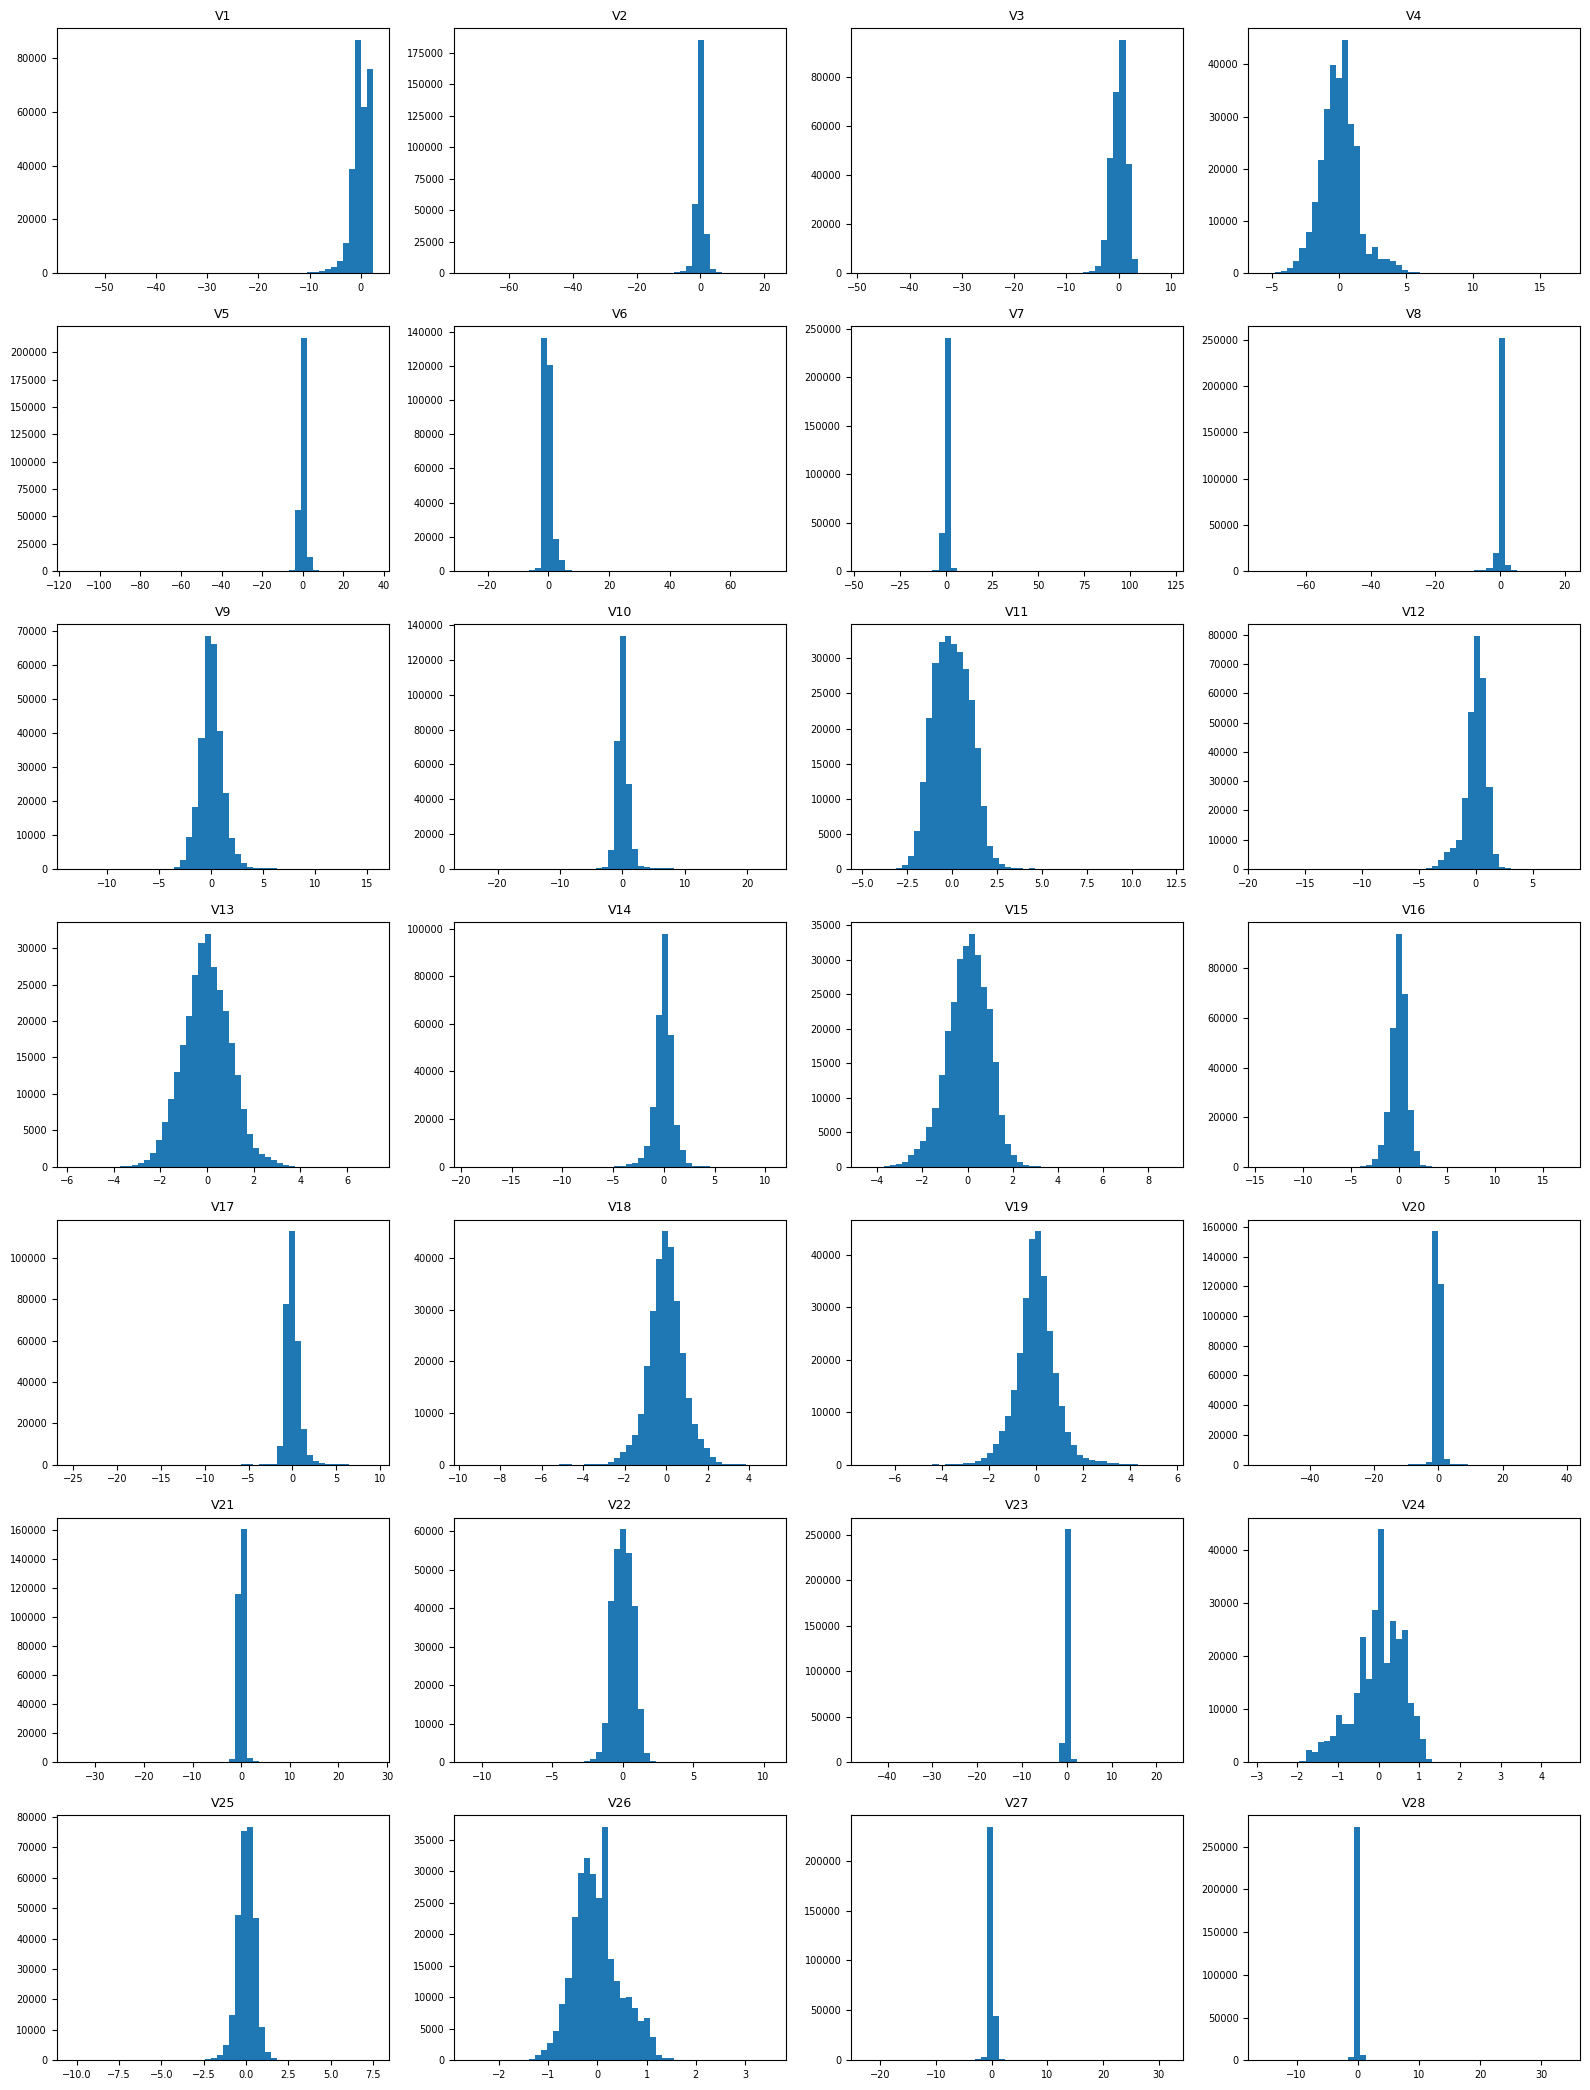

In [33]:
n_features = len(pca_features)
n_cols = 4
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize = (4*n_cols, 3*n_rows))
axes = axes.flatten()

for i, col in enumerate(pca_features):
    axes[i].hist(df[col], bins=50)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(axis="both", which="both", labelsize=7)

plt.tight_layout()
plt.show()

### Model Training

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score, #AUPRC
    precision_recall_curve
)

In [36]:
from xgboost import XGBClassifier

In [37]:
X = df.drop(columns=["Class"]) # this is what we are trying to predict
y = df["Class"]

In [38]:
# we need to scale time and amount with a standard scaler, the rest are already standardised by pca
cols_to_scale = ["Time", "Amount"]
other_cols = [c for c in X.columns if c not in cols_to_scale]

preprocessor = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), cols_to_scale),
        ("pass", "passthrough", other_cols),
    ]
)

In [39]:
# stratification:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    stratify=y,
    random_state=101
)

In [40]:
# for model eval:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    auprc = average_precision_score(y_test, y_score)
    roc_auc = roc_auc_score(y_test, y_score)

    print(f"\n=== {name} ===")
    print(f"AUPRC: {auprc:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print("Confusion Matrix (grain of salt):")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, digits = 4))

    return y_score
        

#### Logistic Regression:

In [43]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight = "balanced", 
    n_jobs=-1 # multi-threaded
)

pipe_lr = Pipeline(
    steps = [
        ("prep", preprocessor),
        ("model", log_reg)
    ]
)

pipe_lr.fit(X_train, y_train)
y_score_lr = evaluate_model("Logistic Regression (balanced)", pipe_lr, X_test, y_test)



=== Logistic Regression (balanced) ===
AUPRC: 0.7552
ROC AUC: 0.9880
Confusion Matrix (grain of salt):
[[55463  1401]
 [    7    91]]

Classification report:
              precision    recall  f1-score   support

           0     0.9999    0.9754    0.9875     56864
           1     0.0610    0.9286    0.1145        98

    accuracy                         0.9753     56962
   macro avg     0.5304    0.9520    0.5510     56962
weighted avg     0.9983    0.9753    0.9860     56962



In [51]:
log_reg = LogisticRegression(
    max_iter=1000,
    #class_weight = "balanced", 
    n_jobs=-1 # multi-threaded
)

pipe_lr = Pipeline(
    steps = [
        ("prep", preprocessor),
        ("model", log_reg)
    ]
)

pipe_lr.fit(X_train, y_train)
y_score_lr = evaluate_model("Logistic Regression (unbalanced)", pipe_lr, X_test, y_test)



=== Logistic Regression (unbalanced) ===
AUPRC: 0.7861
ROC AUC: 0.9795
Confusion Matrix (grain of salt):
[[56856     8]
 [   38    60]]

Classification report:
              precision    recall  f1-score   support

           0     0.9993    0.9999    0.9996     56864
           1     0.8824    0.6122    0.7229        98

    accuracy                         0.9992     56962
   macro avg     0.9408    0.8061    0.8612     56962
weighted avg     0.9991    0.9992    0.9991     56962



In [44]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
scale_pos_weight

np.float64(577.2868020304569)

In [49]:
xgb_clf = XGBClassifier(
    tree_method = "auto",
    #device="cuda",
    #predictor="gpu_predictor",
    max_depth=4,
    n_estimators=500,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss", #binary cross entropy
    random_state=101,
    n_jobs=-1
)

pipe_xgb = Pipeline(
    steps = [
        ("prep", preprocessor),
        ("model", xgb_clf)
    ]
)

pipe_xgb.fit(X_train, y_train)

y_score_xgb = evaluate_model("XGBoost", pipe_xgb, X_test, y_test)


=== XGBoost ===
AUPRC: 0.8982
ROC AUC: 0.9908
Confusion Matrix (grain of salt):
[[56847    17]
 [   11    87]]

Classification report:
              precision    recall  f1-score   support

           0     0.9998    0.9997    0.9998     56864
           1     0.8365    0.8878    0.8614        98

    accuracy                         0.9995     56962
   macro avg     0.9182    0.9437    0.9306     56962
weighted avg     0.9995    0.9995    0.9995     56962



### Comparisons

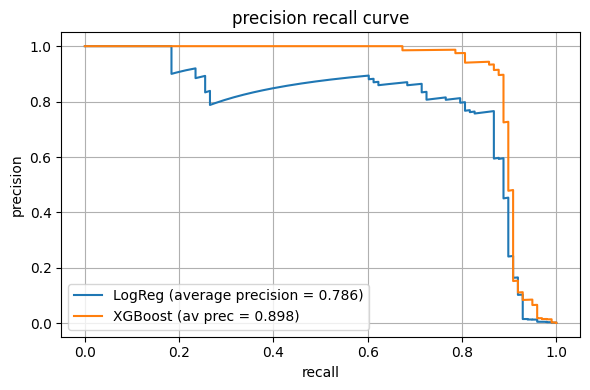

In [53]:
prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_score_lr)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_score_xgb)

ap_lr = average_precision_score(y_test, y_score_lr)
ap_xgb = average_precision_score(y_test, y_score_xgb)

plt.figure(figsize=(6,4))
plt.plot(rec_lr, prec_lr, label=f"LogReg (average precision = {ap_lr:.3f})")
plt.plot(rec_xgb, prec_xgb, label=f"XGBoost (av prec = {ap_xgb:.3f})")
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("precision recall curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Inference

In [54]:
sample = X_test.iloc[[0]]
fraud_prob = pipe_xgb.predict_proba(sample)[:, 1][0]
fraud_prob

np.float32(1.2455843e-05)